## import

In [1]:

import os, sys
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
import cv2
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchmetrics.classification import Accuracy
import timm
from torch.optim.lr_scheduler import CosineAnnealingLR
# from dataloaders import make_loaders
from tqdm.notebook import tqdm

import shutil, uuid
import itertools, hashlib
from sklearn.model_selection import StratifiedGroupKFold

import random

import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

from typing import Tuple, Dict, List

import math
import warnings
from torchvision import transforms
from torchvision.io import read_image
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

In [2]:
# --------- config ----------
DATA_ROOT = Path("/workspace/Dataset_raw")  # adjust if needed
OUT_DIR = Path("metadata"); OUT_DIR.mkdir(parents=True, exist_ok=True)
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
RUN_DUP_CHECK = True  # set to True to enable duplicate image check

# Label maps
species_map = {"mango": 0, "guava": 1, "papaya": 2}
health_map  = {"healthy": 0, "anthracnose": 1}



In [3]:
# --------- crawl & validate ----------
records = []
bad_files = []
for cls_dir in sorted(DATA_ROOT.iterdir()):
    if not cls_dir.is_dir(): 
        continue
    # Expect folder names like Mango_Healthy
    parts = cls_dir.name.split("_")
    if len(parts) != 2:
        print(f"[WARN] Skipping unexpected folder name: {cls_dir.name}")
        continue
    species_raw, health_raw = parts[0].lower(), parts[1].lower()
    if species_raw not in species_map or health_raw not in health_map:
        print(f"[WARN] Unknown labels in {cls_dir.name}; skipping")
        continue

    for p in cls_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in VALID_EXT:
            try:
                with Image.open(p) as img:
                    w, h = img.size
            except (UnidentifiedImageError, OSError) as e:
                bad_files.append((str(p), str(e)))
                continue

            records.append({
                "path": str(p.as_posix()),
                "species": species_raw,
                "disease": health_raw,
                "species_id": species_map[species_raw],
                "disease_id": health_map[health_raw],
                "width": w, "height": h
            })

df = pd.DataFrame.from_records(records)
df.to_csv(OUT_DIR / "images.csv", index=False)

print(f"Total valid images: {len(df)}")
if bad_files:
    pd.DataFrame(bad_files, columns=["path","error"]).to_csv(OUT_DIR / "corrupt_files.csv", index=False)
    print(f"Corrupt/unreadable images logged: {len(bad_files)} -> {OUT_DIR/'corrupt_files.csv'}")



Total valid images: 2538


In [4]:
# --------- summary tables ----------
# Joint class label
df["joint_label"] = df["species"].str.capitalize() + "_" + df["disease"].str.capitalize()
joint_counts = df["joint_label"].value_counts().sort_index()
joint_counts.to_csv(OUT_DIR / "joint_counts.csv", header=["count"])

# Pivot per species: Healthy vs Anthracnose
pivot = pd.pivot_table(df, values="path", index="species", columns="disease", aggfunc="count", fill_value=0)
pivot = pivot.reindex(index=["mango","guava","papaya"], columns=["healthy","anthracnose"])
pivot.to_csv(OUT_DIR / "per_species_counts.csv")

print("\nCounts per joint class:")
print(joint_counts)
print("\nPer-species counts (rows=species, cols=health):")
print(pivot)




Counts per joint class:
joint_label
Guava_Anthracnose     237
Guava_Healthy         727
Mango_Anthracnose     597
Mango_Healthy         500
Papaya_Anthracnose    249
Papaya_Healthy        228
Name: count, dtype: int64

Per-species counts (rows=species, cols=health):
disease  healthy  anthracnose
species                      
mango        500          597
guava        727          237
papaya       228          249


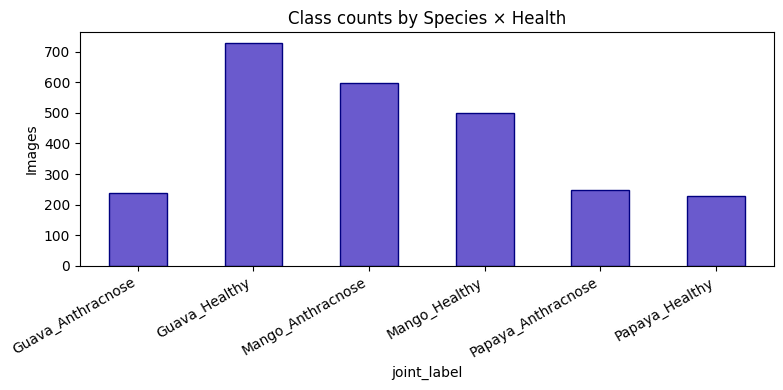

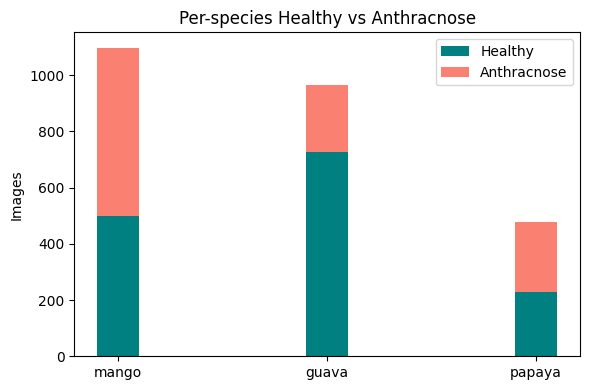

In [5]:
# --------- visualizations ----------
plt.figure(figsize=(8,4))
joint_counts.plot(kind="bar", color="slateblue", edgecolor="navy")
plt.title("Class counts by Species × Health")
plt.ylabel("Images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "imbalance_joint_bar.png", dpi=180)
plt.show()


plt.figure(figsize=(6,4))
species_order = ["mango", "guava", "papaya"]
healthy_counts = pivot["healthy"].reindex(species_order)
disease_counts = pivot["anthracnose"].reindex(species_order)

bar_width = 0.2  # thinner bars (default is ~0.8)

plt.bar(species_order, healthy_counts, 
        label="Healthy", 
        color="teal", 
        width=bar_width)

plt.bar(species_order, disease_counts, 
        bottom=healthy_counts, 
        label="Anthracnose", 
        color="salmon", 
        width=bar_width)

plt.title("Per-species Healthy vs Anthracnose")
plt.ylabel("Images")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "imbalance_stacked_bar.png", dpi=220)
plt.show()



## Visualisation code

In [6]:
# Enable inline plotting for Jupyter
%matplotlib inline

# Set publication-quality style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100  # Lower for notebook display, saved figures will be 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

class TrainingLogger:
    """Logger to track training metrics epoch-by-epoch"""
    def __init__(self):
        self.history = {
            'epoch': [],
            'train_loss': [],
            'val_loss': [],
            'train_acc_species': [],
            'val_acc_species': [],
            'train_acc_health': [],
            'val_acc_health': [],
            'train_acc_both': [],
            'val_acc_both': [],
            'lr': []
        }
    
    def log_epoch(self, epoch, train_stats, val_stats, lr):
        """Log metrics for one epoch"""
        self.history['epoch'].append(epoch)
        self.history['train_loss'].append(train_stats['loss'])
        self.history['val_loss'].append(val_stats['loss'])
        self.history['train_acc_species'].append(train_stats['acc_species'])
        self.history['val_acc_species'].append(val_stats['acc_species'])
        self.history['train_acc_health'].append(train_stats['acc_health'])
        self.history['val_acc_health'].append(val_stats['acc_health'])
        self.history['train_acc_both'].append(train_stats['acc_both'])
        self.history['val_acc_both'].append(val_stats['acc_both'])
        self.history['lr'].append(lr)
    
    def plot_convergence(self, save_path='training_convergence.png', model_name='Model', show=True):
        """
        Create publication-quality convergence plots
        
        Args:
            save_path: Path to save the figure
            model_name: Name of the model for the title
            show: Whether to display the plot in notebook (default: True)
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'{model_name} Training Convergence', fontsize=14, fontweight='bold', y=0.995)
        
        epochs = self.history['epoch']
        
        # Plot 1: Training and Validation Loss
        ax1 = axes[0, 0]
        ax1.plot(epochs, self.history['train_loss'], 'o-', label='Train Loss', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax1.plot(epochs, self.history['val_loss'], 's-', label='Val Loss', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('(a) Multi-task Loss', fontweight='bold', loc='left')
        ax1.legend(framealpha=0.9)
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Species Accuracy
        ax2 = axes[0, 1]
        ax2.plot(epochs, self.history['train_acc_species'], 'o-', label='Train Species', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax2.plot(epochs, self.history['val_acc_species'], 's-', label='Val Species', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('(b) Species Classification', fontweight='bold', loc='left')
        ax2.set_ylim([0, 1.05])
        ax2.legend(framealpha=0.9)
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Disease Accuracy
        ax3 = axes[1, 0]
        ax3.plot(epochs, self.history['train_acc_health'], 'o-', label='Train Disease', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax3.plot(epochs, self.history['val_acc_health'], 's-', label='Val Disease', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Accuracy')
        ax3.set_title('(c) Disease Detection', fontweight='bold', loc='left')
        ax3.set_ylim([0, 1.05])
        ax3.legend(framealpha=0.9)
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Joint Accuracy (Both Correct)
        ax4 = axes[1, 1]
        ax4.plot(epochs, self.history['train_acc_both'], 'o-', label='Train Both', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax4.plot(epochs, self.history['val_acc_both'], 's-', label='Val Both', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        
        # Mark best validation epoch
        best_epoch_idx = np.argmax(self.history['val_acc_both'])
        best_epoch = epochs[best_epoch_idx]
        best_val_both = self.history['val_acc_both'][best_epoch_idx]
        ax4.axvline(x=best_epoch, color='red', linestyle='--', 
                   linewidth=1.5, alpha=0.6, label=f'Best (Epoch {best_epoch})')
        ax4.plot(best_epoch, best_val_both, 'r*', markersize=15, 
                markeredgecolor='darkred', markeredgewidth=1.5)
        
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Accuracy')
        ax4.set_title('(d) Joint Accuracy (Primary Metric)', fontweight='bold', loc='left')
        ax4.set_ylim([0, 1.05])
        ax4.legend(framealpha=0.9)
        ax4.grid(True, alpha=0.3)
        
        # Add annotation for best performance
        ax4.annotate(f'{best_val_both:.3f}', 
                    xy=(best_epoch, best_val_both),
                    xytext=(10, -15), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='red'),
                    fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Convergence plot saved to: {save_path}")
        
        if show:
            plt.show()
        else:
            plt.close()
    
    def plot_learning_rate(self, save_path='learning_rate_schedule.png', show=True):
        """Plot learning rate schedule"""
        fig, ax = plt.subplots(figsize=(10, 4))
        
        epochs = self.history['epoch']
        ax.plot(epochs, self.history['lr'], 'o-', linewidth=2, 
               markersize=5, color='#F18F01', label='Learning Rate')
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Learning Rate')
        ax.set_title('Learning Rate Schedule (Cosine Annealing)', fontweight='bold')
        ax.legend(framealpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')
        
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Learning rate plot saved to: {save_path}")
        
        if show:
            plt.show()
        else:
            plt.close()
    
    def plot_comparison(self, other_loggers, labels, save_path='model_comparison.png', show=True):
        """
        Compare multiple models on the same plot
        
        Args:
            other_loggers: List of other TrainingLogger instances
            labels: List of model names
            save_path: Path to save comparison figure
            show: Whether to display the plot in notebook
        """
        all_loggers = [self] + other_loggers
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle('Multi-Model Performance Comparison', fontsize=14, fontweight='bold')
        
        colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51', '#8B5A3C']
        
        # Plot 1: Validation Loss Comparison
        ax1 = axes[0]
        for i, (logger, label) in enumerate(zip(all_loggers, labels)):
            ax1.plot(logger.history['epoch'], logger.history['val_loss'], 
                    'o-', label=label, linewidth=2, markersize=4, 
                    color=colors[i % len(colors)], alpha=0.8)
        
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Validation Loss')
        ax1.set_title('(a) Validation Loss', fontweight='bold', loc='left')
        ax1.legend(framealpha=0.9, loc='best')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Joint Accuracy Comparison
        ax2 = axes[1]
        for i, (logger, label) in enumerate(zip(all_loggers, labels)):
            ax2.plot(logger.history['epoch'], logger.history['val_acc_both'], 
                    'o-', label=label, linewidth=2, markersize=4, 
                    color=colors[i % len(colors)], alpha=0.8)
        
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Validation Joint Accuracy')
        ax2.set_title('(b) Joint Accuracy (Both Correct)', fontweight='bold', loc='left')
        ax2.set_ylim([0, 1.05])
        ax2.legend(framealpha=0.9, loc='best')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Comparison plot saved to: {save_path}")
        
        if show:
            plt.show()
        else:
            plt.close()
    
    def save_history(self, save_path='training_history.csv'):
        """Save training history to CSV"""
        df = pd.DataFrame(self.history)
        df.to_csv(save_path, index=False)
        print(f"✓ Training history saved to: {save_path}")

print("✓ TrainingLogger class loaded successfully!")

✓ TrainingLogger class loaded successfully!


## training code

In [7]:

# -------------------------------
# Config
# -------------------------------
DATA_ROOT = Path("/workspace/Dataset_split")  
IMG_SIZE  = 224
BATCH_SIZE = 16
NUM_WORKERS = 0  # Set to 0 to avoid multiprocessing issues
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 5e-4
DROPOUT = 0.3
SEED = 42
LOSS_WEIGHT_HEALTH = 1.0
USE_AMP = True
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print("Device:", device)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------------
# Label maps (case-insensitive)
# -------------------------------
SPECIES_MAP = {"guava":0, "mango":1, "papaya":2}
HEALTH_MAP  = {"healthy":0, "anthracnose":1}

def parse_joint_label(folder_name: str) -> Tuple[int,int]:
    name = folder_name.strip()
    if "_" not in name:
        raise ValueError(f"Folder name not joint label: {name}")
    sp, he = name.split("_", 1)
    sp_id = SPECIES_MAP[sp.lower()]
    he_id = HEALTH_MAP[he.lower()]
    return sp_id, he_id

# -------------------------------
# Dataset
# -------------------------------
class JointLeafDataset(Dataset):
    def __init__(self, split_root: Path, transform=None):
        self.split_root = Path(split_root)
        self.samples: List[Tuple[str, int, int]] = []
        self.transform = transform
        for folder in sorted([d for d in self.split_root.iterdir() if d.is_dir()]):
            sp_id, he_id = parse_joint_label(folder.name)
            for p in folder.rglob("*"):
                if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
                    self.samples.append((str(p), sp_id, he_id))
        if len(self.samples) == 0:
            raise RuntimeError(f"No images found under {split_root}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, sp_id, he_id = self.samples[idx]
       
        try:
            img = Image.open(path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {path}: {e}")
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
       
        if self.transform is not None:
            img = self.transform(img)
       
        return img, torch.tensor(sp_id, dtype=torch.long), torch.tensor(he_id, dtype=torch.long)

# -------------------------------
# Transforms
# -------------------------------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# -------------------------------
# Datasets & Loaders
# -------------------------------
print("Loading datasets...")
train_ds = JointLeafDataset(DATA_ROOT / "train", transform=train_tf)
val_ds   = JointLeafDataset(DATA_ROOT / "val",   transform=eval_tf)
test_ds  = JointLeafDataset(DATA_ROOT / "test",  transform=eval_tf)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# Test loading one sample
print("\nTesting sample loading...")
try:
    sample_img, sample_sp, sample_he = train_ds[0]
    print(f"✓ Sample loaded successfully: shape={sample_img.shape}, species={sample_sp}, health={sample_he}")
except Exception as e:
    print(f"✗ Failed to load sample: {e}")
    raise

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))

# Test DataLoader
print("\nTesting DataLoader...")
try:
    for i, (imgs, sp, he) in enumerate(train_loader):
        print(f"✓ Batch {i}: imgs {imgs.shape}, species {sp.shape}, health {he.shape}")
        if i >= 2:
            break
    print("✓ DataLoader test passed!\n")
except Exception as e:
    print(f"✗ DataLoader failed: {e}")
    import traceback
    traceback.print_exc()
    raise



# -------------------------------
# Comprehensive Testing Function
# -------------------------------
def comprehensive_test(model, test_loader, device, species_map, health_map):
    """
    Perform comprehensive testing with metrics and visualizations
    """
    model.eval()
    
    # Storage for predictions and ground truth
    all_species_preds = []
    all_species_true = []
    all_health_preds = []
    all_health_true = []
    all_both_correct = []
    
    # For visualization: store some sample predictions
    sample_images = []
    sample_predictions = []
    sample_ground_truth = []
    max_samples = 20  # Number of samples to visualize
    
    print("Running comprehensive test evaluation...")
    
    with torch.no_grad():
        for batch_idx, (imgs, y_species, y_health) in enumerate(test_loader):
            imgs = imgs.to(device, non_blocking=True)
            y_species = y_species.to(device, non_blocking=True)
            y_health = y_health.to(device, non_blocking=True)
            
            # Get predictions
            logits_species, logits_health = model(imgs)
            preds_species = logits_species.argmax(dim=1)
            preds_health = logits_health.argmax(dim=1)
            
            # Store predictions and ground truth
            all_species_preds.extend(preds_species.cpu().numpy())
            all_species_true.extend(y_species.cpu().numpy())
            all_health_preds.extend(preds_health.cpu().numpy())
            all_health_true.extend(y_health.cpu().numpy())
            
            # Check if both predictions are correct
            both_correct = ((preds_species == y_species) & (preds_health == y_health)).cpu().numpy()
            all_both_correct.extend(both_correct)
            
            # Store samples for visualization
            if len(sample_images) < max_samples:
                for i in range(min(imgs.size(0), max_samples - len(sample_images))):
                    sample_images.append(imgs[i].cpu())
                    sample_predictions.append({
                        'species': preds_species[i].item(),
                        'health': preds_health[i].item()
                    })
                    sample_ground_truth.append({
                        'species': y_species[i].item(),
                        'health': y_health[i].item()
                    })
    
    # Convert to numpy arrays
    all_species_preds = np.array(all_species_preds)
    all_species_true = np.array(all_species_true)
    all_health_preds = np.array(all_health_preds)
    all_health_true = np.array(all_health_true)
    all_both_correct = np.array(all_both_correct)
    
    # Reverse mapping for labels
    species_labels = {v: k.capitalize() for k, v in species_map.items()}
    health_labels = {v: k.capitalize() for k, v in health_map.items()}
    
    # -------------------------------
    # Print Metrics
    # -------------------------------
    print("\n" + "="*80)
    print("COMPREHENSIVE TEST RESULTS")
    print("="*80)
    
    # Overall accuracies
    species_acc = accuracy_score(all_species_true, all_species_preds)
    health_acc = accuracy_score(all_health_true, all_health_preds)
    both_acc = all_both_correct.mean()
    
    print(f"\n{'OVERALL ACCURACIES':^80}")
    print("-"*80)
    print(f"  Species Classification:  {species_acc:.4f} ({species_acc*100:.2f}%)")
    print(f"  Health Classification:   {health_acc:.4f} ({health_acc*100:.2f}%)")
    print(f"  Both Correct (Joint):    {both_acc:.4f} ({both_acc*100:.2f}%)")
    
    # Species Classification Report
    print(f"\n{'SPECIES CLASSIFICATION REPORT':^80}")
    print("-"*80)
    print(classification_report(
        all_species_true, 
        all_species_preds,
        target_names=[species_labels[i] for i in sorted(species_labels.keys())],
        digits=4
    ))
    
    # Health Classification Report
    print(f"\n{'HEALTH/DISEASE CLASSIFICATION REPORT':^80}")
    print("-"*80)
    print(classification_report(
        all_health_true, 
        all_health_preds,
        target_names=[health_labels[i] for i in sorted(health_labels.keys())],
        digits=4
    ))
    
    # Per-class joint accuracy
    print(f"\n{'PER-CLASS JOINT ACCURACY':^80}")
    print("-"*80)
    for sp_id in sorted(species_labels.keys()):
        for he_id in sorted(health_labels.keys()):
            # Find samples of this joint class
            mask = (all_species_true == sp_id) & (all_health_true == he_id)
            if mask.sum() > 0:
                joint_acc = all_both_correct[mask].mean()
                count = mask.sum()
                sp_name = species_labels[sp_id]
                he_name = health_labels[he_id]
                print(f"  {sp_name:8s} + {he_name:12s}: {joint_acc:.4f} ({joint_acc*100:.2f}%) [{count:4d} samples]")
    
    # -------------------------------
    # Visualizations - Individual Images
    # -------------------------------
    
    # 1. Species Confusion Matrix (Individual)
    fig, ax = plt.subplots(figsize=(8, 6))
    cm_species = confusion_matrix(all_species_true, all_species_preds)
    sns.heatmap(cm_species, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[species_labels[i] for i in sorted(species_labels.keys())],
                yticklabels=[species_labels[i] for i in sorted(species_labels.keys())])
    ax.set_title(f'Species Classification\nAccuracy: {species_acc:.2%}', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('confusion_matrix_species.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved species confusion matrix to 'confusion_matrix_species.png'")
    plt.close()
    
    #

Device: cuda
Loading datasets...
Train: 4380 | Val: 485 | Test: 499

Testing sample loading...
✓ Sample loaded successfully: shape=torch.Size([3, 224, 224]), species=0, health=1

Testing DataLoader...
✓ Batch 0: imgs torch.Size([16, 3, 224, 224]), species torch.Size([16]), health torch.Size([16])
✓ Batch 1: imgs torch.Size([16, 3, 224, 224]), species torch.Size([16]), health torch.Size([16])
✓ Batch 2: imgs torch.Size([16, 3, 224, 224]), species torch.Size([16]), health torch.Size([16])
✓ DataLoader test passed!



## Model Definition

In [8]:
# -------------------------------
# Model
# -------------------------------
class MultiTaskEfficientNetB4(nn.Module):
    def __init__(self, num_species=3, num_health=2, pretrained=False, dropout=0.3):
        super().__init__()
        if pretrained:
            weights = EfficientNet_B4_Weights.IMAGENET1K_V1
            self.backbone = efficientnet_b4(weights=weights)
        else:
            self.backbone = efficientnet_b4(weights=None)
        
        # EfficientNet has classifier as a Sequential with Linear layer at index [1]
        in_dim = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        
        self.dropout = nn.Dropout(dropout)
        self.head_species = nn.Linear(in_dim, num_species)
        self.head_health = nn.Linear(in_dim, num_health)
    
    def forward(self, x):
        feats = self.backbone(x)
        feats = self.dropout(feats)
        logits_species = self.head_species(feats)
        logits_health = self.head_health(feats)
        return logits_species, logits_health

print("Initializing model...")
model = MultiTaskEfficientNetB4(num_species=3, num_health=2, pretrained=False, dropout=DROPOUT).to(device)
print("Model loaded\n")

# -------------------------------
# Optimizer / Scheduler / Losses
# -------------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion_species = nn.CrossEntropyLoss()
criterion_health  = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and device.type=="cuda")

# -------------------------------
# Utilities
# -------------------------------
def accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

def run_epoch(loader, model, optimizer=None, train=True, epoch=0):
    if train:
        model.train()
    else:
        model.eval()
    
    running = {
        "loss": 0.0,
        "acc_species": 0.0,
        "acc_health":  0.0,
        "acc_both":    0.0,
        "n": 0
    }
    total_batches = len(loader)
   
    for batch_idx, (imgs, y_species, y_health) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        y_species = y_species.to(device, non_blocking=True)
        y_health  = y_health.to(device, non_blocking=True)
        
        with torch.set_grad_enabled(train):
            if USE_AMP and device.type=="cuda":
                with torch.amp.autocast('cuda'):
                    logits_species, logits_health = model(imgs)
                    loss = criterion_species(logits_species, y_species) + \
                           LOSS_WEIGHT_HEALTH * criterion_health(logits_health, y_health)
            else:
                logits_species, logits_health = model(imgs)
                loss = criterion_species(logits_species, y_species) + \
                       LOSS_WEIGHT_HEALTH * criterion_health(logits_health, y_health)
        
        if train:
            optimizer.zero_grad(set_to_none=True)
            if USE_AMP and device.type=="cuda":
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
        
        acc_sp = accuracy(logits_species, y_species)
        acc_he = accuracy(logits_health, y_health)
        preds_sp = logits_species.argmax(1)
        preds_he = logits_health.argmax(1)
        acc_both = ((preds_sp == y_species) & (preds_he == y_health)).float().mean().item()
        
        bs = imgs.size(0)
        running["loss"] += loss.item() * bs
        running["acc_species"] += acc_sp * bs
        running["acc_health"]  += acc_he * bs
        running["acc_both"]    += acc_both * bs
        running["n"] += bs
        
        if (batch_idx + 1) % max(1, total_batches // 10) == 0 or (batch_idx + 1) == total_batches:
            avg_loss = running["loss"] / running["n"]
            avg_sp = running["acc_species"] / running["n"]
            avg_he = running["acc_health"] / running["n"]
            avg_both = running["acc_both"] / running["n"]
            print(f"  [{batch_idx + 1}/{total_batches}] loss: {avg_loss:.4f}, sp: {avg_sp:.3f}, he: {avg_he:.3f}, both: {avg_both:.3f}")
    
    for k in ["loss", "acc_species", "acc_health", "acc_both"]:
        running[k] /= max(1, running["n"])
    return running

Initializing model...
Model loaded



/tmp/ipykernel_2434/3072071163.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and device.type=="cuda")


## Training Loop

In [9]:
# -------------------------------
# Training Loop
# -------------------------------

# Storage for history
history = {
    "train_loss": [], "val_loss": [],
    "train_acc_species": [], "val_acc_species": [],
    "train_acc_health": [], "val_acc_health": [],
    "train_acc_both": [], "val_acc_both": []
}

best_val_both = 0.0
best_epoch = 0
patience = 5
epochs_without_improvement = 0

print("="*80)
print("STARTING TRAINING")
print("="*80)

for epoch in range(EPOCHS):
    print(f"\n{'='*80}")
    print(f"Epoch {epoch+1}/{EPOCHS} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    print(f"{'='*80}")
    
    # Train
    print("Training...")
    train_stats = run_epoch(train_loader, model, optimizer, train=True, epoch=epoch)
    
    # Validate
    print("Validating...")
    val_stats = run_epoch(val_loader, model, optimizer=None, train=False, epoch=epoch)
    
    # Update scheduler
    scheduler.step()
    
    # Store history
    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["train_acc_species"].append(train_stats["acc_species"])
    history["val_acc_species"].append(val_stats["acc_species"])
    history["train_acc_health"].append(train_stats["acc_health"])
    history["val_acc_health"].append(val_stats["acc_health"])
    history["train_acc_both"].append(train_stats["acc_both"])
    history["val_acc_both"].append(val_stats["acc_both"])
    
    # Print summary
    print(f"\n{'EPOCH SUMMARY':^80}")
    print("-"*80)
    print(f"  Train - Loss: {train_stats['loss']:.4f} | Species: {train_stats['acc_species']:.3f} | "
          f"Health: {train_stats['acc_health']:.3f} | Both: {train_stats['acc_both']:.3f}")
    print(f"  Val   - Loss: {val_stats['loss']:.4f} | Species: {val_stats['acc_species']:.3f} | "
          f"Health: {val_stats['acc_health']:.3f} | Both: {val_stats['acc_both']:.3f}")
    
    # Save best model and check for improvement
    if val_stats["acc_both"] > best_val_both:
        best_val_both = val_stats["acc_both"]
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "val_both": best_val_both
        }, "best_multitask_EF_B4.pt")
        print(f"  ★ New best model saved! Val Both Acc: {best_val_both:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement. Epochs without improvement: {epochs_without_improvement}/{patience}")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\n{'⚠ EARLY STOPPING TRIGGERED':^80}")
        print(f"No improvement for {patience} epochs. Stopping training.")
        break
    
    print(f"{'='*80}\n")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"Best epoch: {best_epoch+1} with val_both={best_val_both:.4f}")
print(f"Total epochs trained: {epoch+1}/{EPOCHS}")

STARTING TRAINING

Epoch 1/50 | LR: 1.00e-04
Training...
  [27/274] loss: 1.8057, sp: 0.438, he: 0.516, both: 0.227
  [54/274] loss: 1.7572, sp: 0.465, he: 0.493, both: 0.231
  [81/274] loss: 1.7119, sp: 0.481, he: 0.505, both: 0.245
  [108/274] loss: 1.6926, sp: 0.493, he: 0.512, both: 0.259
  [135/274] loss: 1.6715, sp: 0.505, he: 0.511, both: 0.264
  [162/274] loss: 1.6390, sp: 0.530, he: 0.516, both: 0.280
  [189/274] loss: 1.6142, sp: 0.546, he: 0.518, both: 0.290
  [216/274] loss: 1.5917, sp: 0.564, he: 0.518, both: 0.299
  [243/274] loss: 1.5722, sp: 0.577, he: 0.523, both: 0.309
  [270/274] loss: 1.5466, sp: 0.594, he: 0.526, both: 0.319
  [274/274] loss: 1.5430, sp: 0.596, he: 0.527, both: 0.321
Validating...
  [3/31] loss: 1.1820, sp: 0.938, he: 0.292, both: 0.271
  [6/31] loss: 1.1521, sp: 0.865, he: 0.625, both: 0.521
  [9/31] loss: 1.1239, sp: 0.868, he: 0.743, both: 0.632
  [12/31] loss: 1.0997, sp: 0.875, he: 0.802, both: 0.693
  [15/31] loss: 1.1277, sp: 0.858, he: 0.75

In [10]:
# -------------------------------
# Test the best model
# -------------------------------

MODEL_NAME = "best_multitask_EF_B4.pt"

print("Testing best model on test set...")
checkpoint = torch.load("best_multitask_EF_B4.pt", map_location=device)
model.load_state_dict(checkpoint["model"])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with val_both={checkpoint['val_both']:.3f}")

# Running the test phase
test_stats = run_epoch(test_loader, model, optimizer=None, train=False)
print(f"\n{'TEST SET RESULTS':^80}")
print("-"*80)
print(f"  Loss: {test_stats['loss']:.4f}")
print(f"  Species Accuracy: {test_stats['acc_species']:.4f} ({test_stats['acc_species']*100:.2f}%)")
print(f"  Health Accuracy:  {test_stats['acc_health']:.4f} ({test_stats['acc_health']*100:.2f}%)")
print(f"  Both Correct:     {test_stats['acc_both']:.4f} ({test_stats['acc_both']*100:.2f}%)")
print("-"*80 + "\n")

# Save final model
torch.save({"model": model.state_dict(),
            "epoch": EPOCHS - 1,
            "test_stats": test_stats,
            "spec": {"species_map": SPECIES_MAP, "health_map": HEALTH_MAP}},
           "final_multitask_EF_B4.pt")
print("✓ Saved final model as 'final_multitask_EF_B4.pt'\n")


# -------------------------------
# Final test phase (Additional)
# -------------------------------
print("="*80)
print("Running Final Test")
print("="*80 + "\n")

with torch.no_grad():
    final_test_stats = run_epoch(test_loader, model, optimizer=None, train=False, epoch=EPOCHS-1)

# Display Final Test Results
print("\n" + "="*80)
print("Final Test Results:")
print(f"  loss: {final_test_stats['loss']:.4f} | species: {final_test_stats['acc_species']:.3f} | health: {final_test_stats['acc_health']:.3f} | both: {final_test_stats['acc_both']:.3f}")
print("="*80)

# -------------------------------
# Summary & Visualizations
# -------------------------------
print(f"\nTraining completed for {MODEL_NAME}")
print(f"Best validation both accuracy: {best_val_both:.3f}")

# Visualizations saved:
print(f"  - convergence_{MODEL_NAME.lower().replace('-', '_')}.png")
print(f"  - lr_schedule_{MODEL_NAME.lower().replace('-', '_')}.png")
print(f"  - history_{MODEL_NAME.lower().replace('-', '_')}.csv")
print("="*80)


Testing best model on test set...
Loaded best model from epoch 19 with val_both=0.953
  [3/32] loss: 0.2625, sp: 1.000, he: 0.896, both: 0.896
  [6/32] loss: 0.1784, sp: 1.000, he: 0.938, both: 0.938
  [9/32] loss: 0.1466, sp: 1.000, he: 0.958, both: 0.958
  [12/32] loss: 0.1277, sp: 1.000, he: 0.969, both: 0.969
  [15/32] loss: 0.1276, sp: 1.000, he: 0.971, both: 0.971
  [18/32] loss: 0.1489, sp: 0.990, he: 0.976, both: 0.965
  [21/32] loss: 0.1494, sp: 0.982, he: 0.970, both: 0.952
  [24/32] loss: 0.1372, sp: 0.984, he: 0.974, both: 0.958
  [27/32] loss: 0.1312, sp: 0.986, he: 0.975, both: 0.961
  [30/32] loss: 0.1293, sp: 0.988, he: 0.973, both: 0.960
  [32/32] loss: 0.1298, sp: 0.988, he: 0.974, both: 0.962

                                TEST SET RESULTS                                
--------------------------------------------------------------------------------
  Loss: 0.1298
  Species Accuracy: 0.9880 (98.80%)
  Health Accuracy:  0.9739 (97.39%)
  Both Correct:     0.9619 (9

## plot saving

In [11]:
# -------------------------------
# Save Individual Training Plots
# -------------------------------
print("\nGenerating individual training plots...")

epochs_range = range(1, len(history['train_loss']) + 1)

# 1. Training Loss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_train_loss.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_train_loss.png")
plt.close()

# 2. Validation Loss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['val_loss'], 'r-o', label='Validation Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Validation Loss Over Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_val_loss.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_val_loss.png")
plt.close()

# 3. Train vs Val Loss Comparison
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_loss_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_loss_comparison.png")
plt.close()

# 4. Species Accuracy
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_acc_species'], 'b-o', label='Train Species Acc', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_acc_species'], 'r-o', label='Val Species Acc', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Species Classification Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_species_accuracy.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_species_accuracy.png")
plt.close()

# 5. Health Accuracy
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_acc_health'], 'b-o', label='Train Health Acc', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_acc_health'], 'r-o', label='Val Health Acc', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Health/Disease Classification Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_health_accuracy.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_health_accuracy.png")
plt.close()

# 6. Joint (Both) Accuracy
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_acc_both'], 'b-o', label='Train Both Acc', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_acc_both'], 'r-o', label='Val Both Acc', linewidth=2, markersize=6)
ax.axhline(y=best_val_both, color='g', linestyle='--', linewidth=2, label=f'Best Val Both: {best_val_both:.3f}')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Joint Classification Accuracy (Both Tasks Correct)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_joint_accuracy.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_joint_accuracy.png")
plt.close()

# 7. All Accuracies Together (Optional comprehensive view)
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(epochs_range, history['train_acc_species'], 'b-o', label='Train Species', linewidth=2, markersize=5)
ax.plot(epochs_range, history['val_acc_species'], 'b--s', label='Val Species', linewidth=2, markersize=5)
ax.plot(epochs_range, history['train_acc_health'], 'g-o', label='Train Health', linewidth=2, markersize=5)
ax.plot(epochs_range, history['val_acc_health'], 'g--s', label='Val Health', linewidth=2, markersize=5)
ax.plot(epochs_range, history['train_acc_both'], 'r-o', label='Train Both', linewidth=2, markersize=5)
ax.plot(epochs_range, history['val_acc_both'], 'r--s', label='Val Both', linewidth=2, markersize=5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('All Metrics Over Training', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_all_metrics.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_all_metrics.png")
plt.close()

print("\n" + "="*80)
print("All training plots saved:")
print("  - plot_train_loss.png")
print("  - plot_val_loss.png")
print("  - plot_loss_comparison.png")
print("  - plot_species_accuracy.png")
print("  - plot_health_accuracy.png")
print("  - plot_joint_accuracy.png")
print("  - plot_all_metrics.png")
print("="*80 + "\n")


Generating individual training plots...
✓ Saved plot_train_loss.png
✓ Saved plot_val_loss.png
✓ Saved plot_loss_comparison.png
✓ Saved plot_species_accuracy.png
✓ Saved plot_health_accuracy.png
✓ Saved plot_joint_accuracy.png
✓ Saved plot_all_metrics.png

All training plots saved:
  - plot_train_loss.png
  - plot_val_loss.png
  - plot_loss_comparison.png
  - plot_species_accuracy.png
  - plot_health_accuracy.png
  - plot_joint_accuracy.png
  - plot_all_metrics.png



## metrics

Loaded best model from epoch 19 with val_both=0.953
Running comprehensive test evaluation...

COMPREHENSIVE TEST RESULTS

                               OVERALL ACCURACIES                               
--------------------------------------------------------------------------------
  Species Classification:  0.9880 (98.80%)
  Health Classification:   0.9739 (97.39%)
  Both Correct (Joint):    0.9619 (96.19%)

                         SPECIES CLASSIFICATION REPORT                          
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

       Guava     0.9744    1.0000    0.9870       228
       Mango     1.0000    0.9669    0.9831       181
      Papaya     1.0000    1.0000    1.0000        90

    accuracy                         0.9880       499
   macro avg     0.9915    0.9890    0.9901       499
weighted avg     0.9883    0.9880    0.9880       499


                      HEALTH/DISEASE CLASS

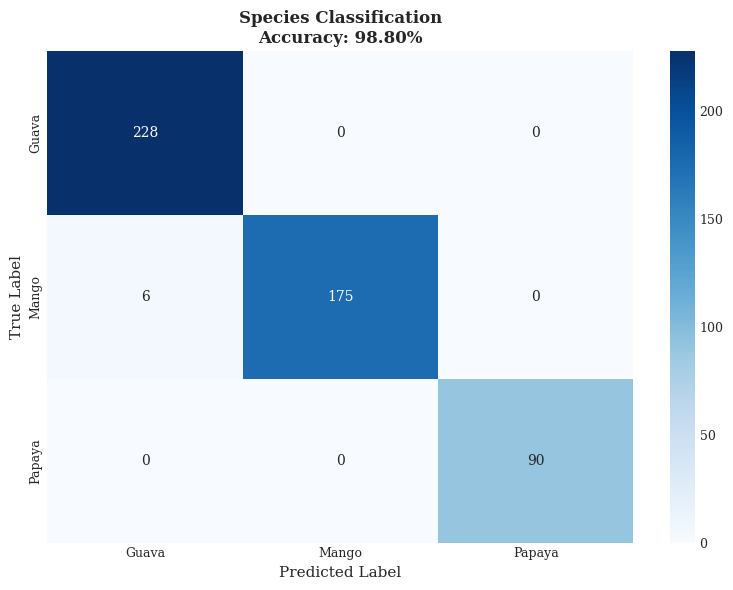

Saved health confusion matrix to 'confusion_matrix_health.png'


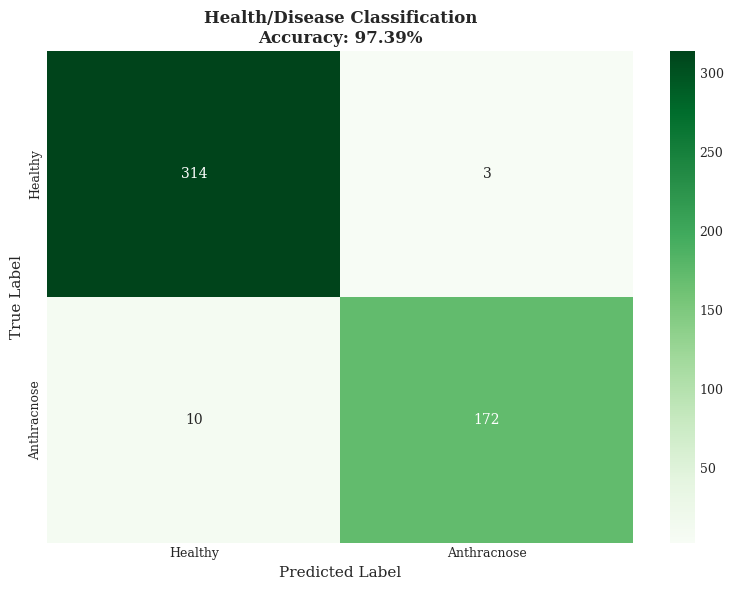

Saved joint accuracy heatmap to 'joint_accuracy_heatmap.png'


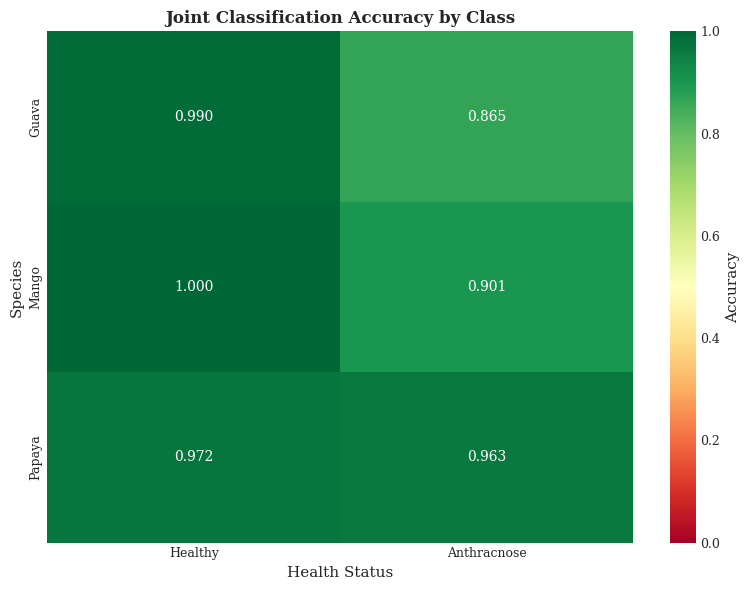


Testing complete! Generated visualizations:
  - confusion_matrices.png
  - sample_predictions.png
  - joint_accuracy_heatmap.png



In [12]:

# -------------------------------
# Comprehensive Testing Function
# -------------------------------
def comprehensive_test(model, test_loader, device, species_map, health_map):
    """
    Perform comprehensive testing with metrics and visualizations
    """
    model.eval()
    
    # Storage for predictions and ground truth
    all_species_preds = []
    all_species_true = []
    all_health_preds = []
    all_health_true = []
    all_both_correct = []
    
    # For visualization: store some sample predictions
    sample_images = []
    sample_predictions = []
    sample_ground_truth = []
    max_samples = 20  # Number of samples to visualize
    
    print("Running comprehensive test evaluation...")
    
    with torch.no_grad():
        for batch_idx, (imgs, y_species, y_health) in enumerate(test_loader):
            imgs = imgs.to(device, non_blocking=True)
            y_species = y_species.to(device, non_blocking=True)
            y_health = y_health.to(device, non_blocking=True)
            
            # Get predictions
            logits_species, logits_health = model(imgs)
            preds_species = logits_species.argmax(dim=1)
            preds_health = logits_health.argmax(dim=1)
            
            # Store predictions and ground truth
            all_species_preds.extend(preds_species.cpu().numpy())
            all_species_true.extend(y_species.cpu().numpy())
            all_health_preds.extend(preds_health.cpu().numpy())
            all_health_true.extend(y_health.cpu().numpy())
            
            # Check if both predictions are correct
            both_correct = ((preds_species == y_species) & (preds_health == y_health)).cpu().numpy()
            all_both_correct.extend(both_correct)
            
            # Store samples for visualization
            if len(sample_images) < max_samples:
                for i in range(min(imgs.size(0), max_samples - len(sample_images))):
                    sample_images.append(imgs[i].cpu())
                    sample_predictions.append({
                        'species': preds_species[i].item(),
                        'health': preds_health[i].item()
                    })
                    sample_ground_truth.append({
                        'species': y_species[i].item(),
                        'health': y_health[i].item()
                    })
    
    # Convert to numpy arrays
    all_species_preds = np.array(all_species_preds)
    all_species_true = np.array(all_species_true)
    all_health_preds = np.array(all_health_preds)
    all_health_true = np.array(all_health_true)
    all_both_correct = np.array(all_both_correct)
    
    # Reverse mapping for labels
    species_labels = {v: k.capitalize() for k, v in species_map.items()}
    health_labels = {v: k.capitalize() for k, v in health_map.items()}
    
    # -------------------------------
    # Print Metrics
    # -------------------------------
    print("\n" + "="*80)
    print("COMPREHENSIVE TEST RESULTS")
    print("="*80)
    
    # Overall accuracies
    species_acc = accuracy_score(all_species_true, all_species_preds)
    health_acc = accuracy_score(all_health_true, all_health_preds)
    both_acc = all_both_correct.mean()
    
    print(f"\n{'OVERALL ACCURACIES':^80}")
    print("-"*80)
    print(f"  Species Classification:  {species_acc:.4f} ({species_acc*100:.2f}%)")
    print(f"  Health Classification:   {health_acc:.4f} ({health_acc*100:.2f}%)")
    print(f"  Both Correct (Joint):    {both_acc:.4f} ({both_acc*100:.2f}%)")
    
    # Species Classification Report
    print(f"\n{'SPECIES CLASSIFICATION REPORT':^80}")
    print("-"*80)
    print(classification_report(
        all_species_true, 
        all_species_preds,
        target_names=[species_labels[i] for i in sorted(species_labels.keys())],
        digits=4
    ))
    
    # Health Classification Report
    print(f"\n{'HEALTH/DISEASE CLASSIFICATION REPORT':^80}")
    print("-"*80)
    print(classification_report(
        all_health_true, 
        all_health_preds,
        target_names=[health_labels[i] for i in sorted(health_labels.keys())],
        digits=4
    ))
    
    # Per-class joint accuracy
    print(f"\n{'PER-CLASS JOINT ACCURACY':^80}")
    print("-"*80)
    for sp_id in sorted(species_labels.keys()):
        for he_id in sorted(health_labels.keys()):
            # Find samples of this joint class
            mask = (all_species_true == sp_id) & (all_health_true == he_id)
            if mask.sum() > 0:
                joint_acc = all_both_correct[mask].mean()
                count = mask.sum()
                sp_name = species_labels[sp_id]
                he_name = health_labels[he_id]
                print(f"  {sp_name:8s} + {he_name:12s}: {joint_acc:.4f} ({joint_acc*100:.2f}%) [{count:4d} samples]")
    
    # -------------------------------
    # Visualizations
    # -------------------------------
    
    # 1. Confusion Matrices - Individual Images

    # Species confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    cm_species = confusion_matrix(all_species_true, all_species_preds)
    sns.heatmap(cm_species, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[species_labels[i] for i in sorted(species_labels.keys())],
                yticklabels=[species_labels[i] for i in sorted(species_labels.keys())])
    ax.set_title(f'Species Classification\nAccuracy: {species_acc:.2%}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('confusion_matrix_species.png', dpi=150, bbox_inches='tight')
    print(f"Saved species confusion matrix to 'confusion_matrix_species.png'")
    plt.show()
    plt.close()


    # Health confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    cm_health = confusion_matrix(all_health_true, all_health_preds)
    sns.heatmap(cm_health, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=[health_labels[i] for i in sorted(health_labels.keys())],
                yticklabels=[health_labels[i] for i in sorted(health_labels.keys())])
    ax.set_title(f'Health/Disease Classification\nAccuracy: {health_acc:.2%}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('confusion_matrix_health.png', dpi=150, bbox_inches='tight')
    print(f"Saved health confusion matrix to 'confusion_matrix_health.png'")
    plt.show()
    plt.close()
   
    
    
    
    # 3. Joint Accuracy Heatmap
    fig, ax = plt.subplots(figsize=(8, 6))
    joint_acc_matrix = np.zeros((len(species_labels), len(health_labels)))
    
    for sp_id in sorted(species_labels.keys()):
        for he_id in sorted(health_labels.keys()):
            mask = (all_species_true == sp_id) & (all_health_true == he_id)
            if mask.sum() > 0:
                joint_acc_matrix[sp_id, he_id] = all_both_correct[mask].mean()
    
    sns.heatmap(joint_acc_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
                xticklabels=[health_labels[i] for i in sorted(health_labels.keys())],
                yticklabels=[species_labels[i] for i in sorted(species_labels.keys())],
                vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Accuracy'})
    ax.set_title('Joint Classification Accuracy by Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Species')
    ax.set_xlabel('Health Status')
    
    plt.tight_layout()
    plt.savefig('joint_accuracy_heatmap.png', dpi=150, bbox_inches='tight')
    print(f"Saved joint accuracy heatmap to 'joint_accuracy_heatmap.png'")
    plt.show()
    plt.close()
    
    print("\n" + "="*80)
    print("Testing complete! Generated visualizations:")
    print("  - confusion_matrices.png")
    print("  - sample_predictions.png")
    print("  - joint_accuracy_heatmap.png")
    print("="*80 + "\n")
    
    return {
        'species_accuracy': species_acc,
        'health_accuracy': health_acc,
        'joint_accuracy': both_acc,
        'species_preds': all_species_preds,
        'species_true': all_species_true,
        'health_preds': all_health_preds,
        'health_true': all_health_true
    }


# -------------------------------
# Usage: Run after training
# -------------------------------

# Load the best model
checkpoint = torch.load("best_multitask_EF_B4.pt", map_location=device)
model.load_state_dict(checkpoint["model"])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with val_both={checkpoint['val_both']:.3f}")

# Run comprehensive testing
test_results = comprehensive_test(
    model=model,
    test_loader=test_loader,
    device=device,
    species_map=SPECIES_MAP,
    health_map=HEALTH_MAP
)

# 10 sample visualisation from 3 class

Saved sample predictions (30 total: 10 per class) to 'sample_predictions.png'


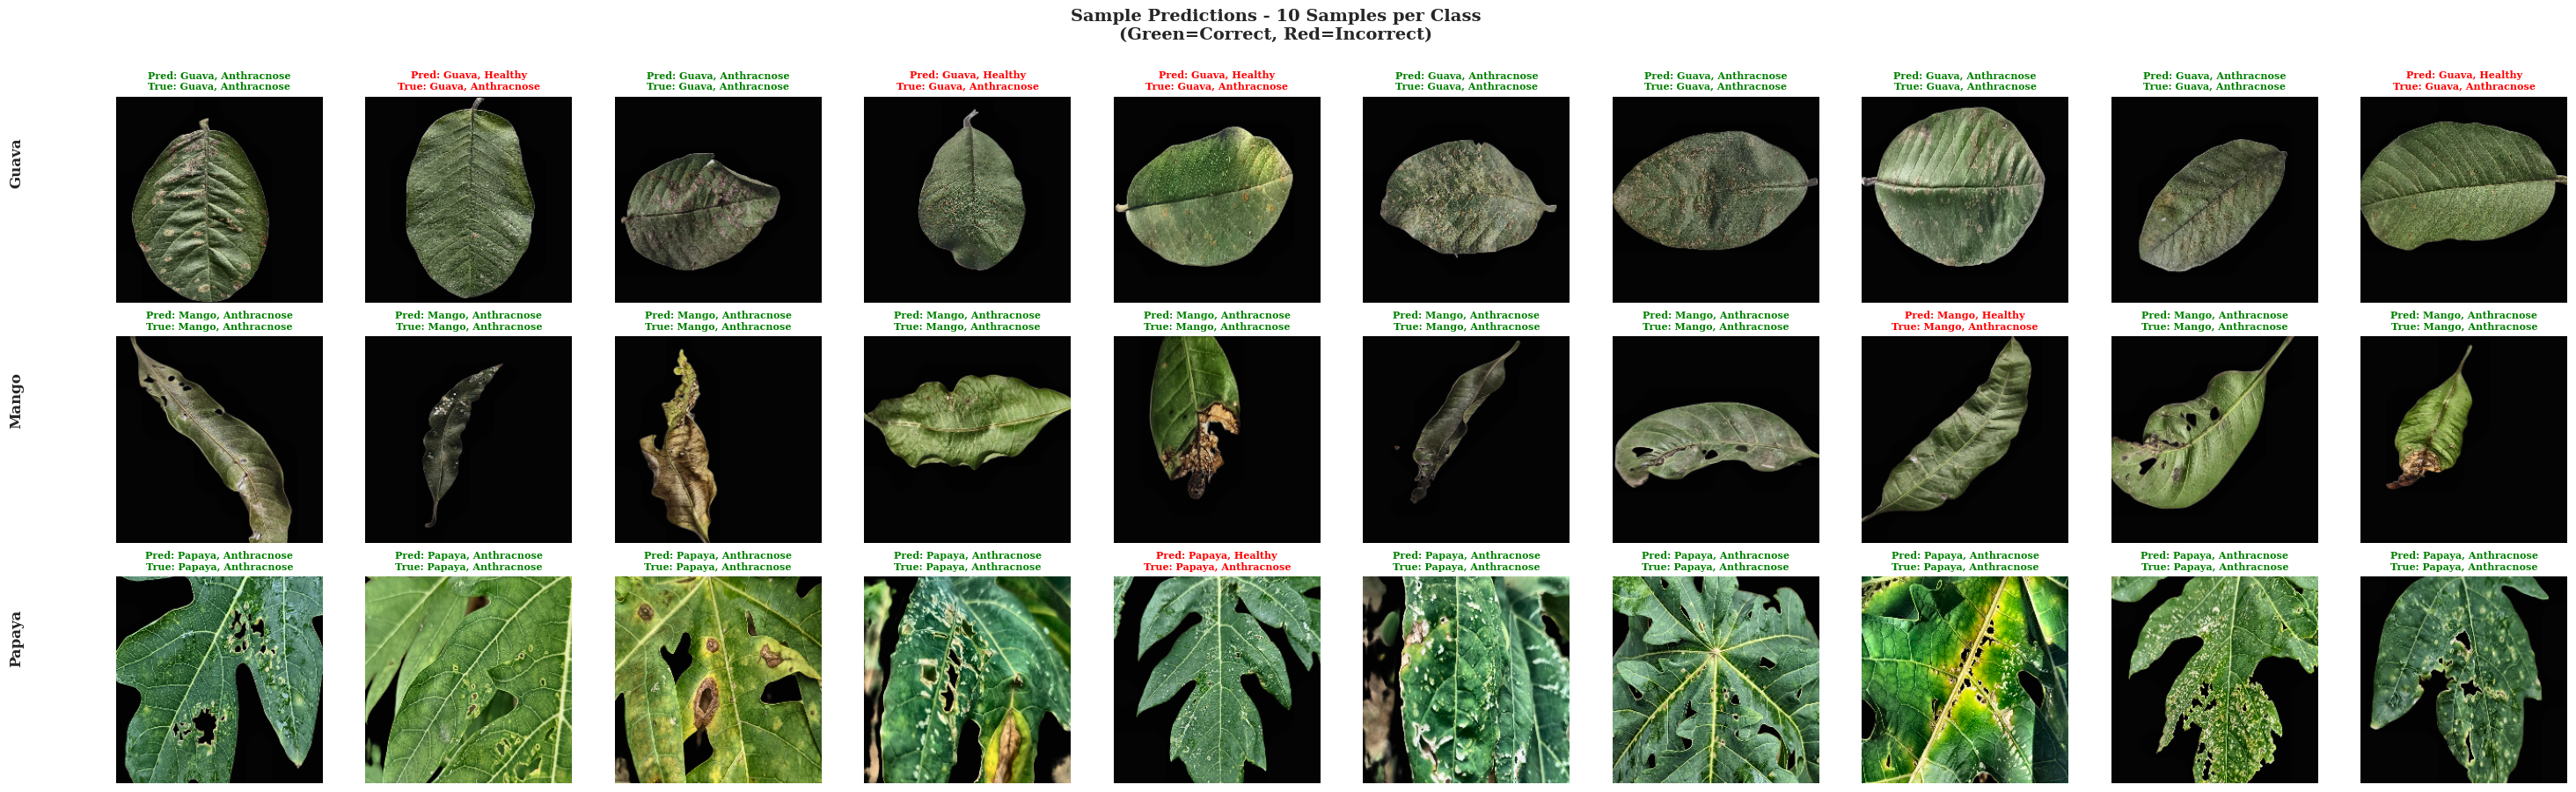

In [13]:
# Load model
# Define your label mappings
species_labels = {
    0: 'Guava',
    1: 'Mango',
    2: 'Papaya'
}

health_labels = {
    0: 'Healthy',
    1: 'Anthracnose',
}
checkpoint = torch.load("best_multitask_EF_B4.pt")
model.load_state_dict(checkpoint["model"])
model.eval()

# Number of samples to display per class
amount = 10

# Collect samples from validation set
sample_images_by_class = {0: [], 1: [], 2: []}
sample_predictions_by_class = {0: [], 1: [], 2: []}
sample_ground_truth_by_class = {0: [], 1: [], 2: []}

with torch.no_grad():
    for images, species_batch, health_batch in val_loader:
        images = images.to(device)
        
        outputs = model(images)
        species_preds = outputs[0].argmax(1)
        health_preds = outputs[1].argmax(1)
        
        for i in range(len(images)):
            species_class = species_batch[i].item()
            
            if len(sample_images_by_class[species_class]) < amount:
                sample_images_by_class[species_class].append(images[i].cpu())
                sample_predictions_by_class[species_class].append({
                    'species': species_preds[i].item(),
                    'health': health_preds[i].item()
                })
                sample_ground_truth_by_class[species_class].append({
                    'species': species_batch[i].item(),
                    'health': health_batch[i].item()
                })
        
        if all(len(samples) >= amount for samples in sample_images_by_class.values()):
            break

# Visualize
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(3, amount, figsize=(3*amount, 9))

for row, species_idx in enumerate(sorted(sample_images_by_class.keys())):
    for col in range(amount):
        ax = axes[row, col]
        
        img = sample_images_by_class[species_idx][col]
        pred = sample_predictions_by_class[species_idx][col]
        gt = sample_ground_truth_by_class[species_idx][col]
        
        # Denormalize and display
        img_display = img.numpy().transpose(1, 2, 0)
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)
        
        ax.imshow(img_display)
        ax.axis('off')
        
        # Check correctness
        both_correct = (pred['species'] == gt['species']) and (pred['health'] == gt['health'])
        
        # Create title
        pred_sp = species_labels[pred['species']]
        pred_he = health_labels[pred['health']]
        gt_sp = species_labels[gt['species']]
        gt_he = health_labels[gt['health']]
        
        title = f"Pred: {pred_sp}, {pred_he}\nTrue: {gt_sp}, {gt_he}"
        color = 'green' if both_correct else 'red'
        ax.set_title(title, fontsize=8, color=color, fontweight='bold')
    
    # Add species label
    fig.text(0.02, 0.5 + (1 - row) * 0.3, species_labels[species_idx], 
             fontsize=12, fontweight='bold', va='center', rotation=90)

plt.suptitle(f'Sample Predictions - {amount} Samples per Class\n(Green=Correct, Red=Incorrect)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0.05, 0, 1, 0.99])
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
print(f"Saved sample predictions ({3*amount} total: {amount} per class) to 'sample_predictions.png'")
plt.show()
plt.close()